Given the root of a binary search tree, and an integer k, return the kth smallest value (1-indexed) in the tree.

A binary search tree satisfies the following constraints:

The left subtree of every node contains only nodes with keys less than the node's key.

The right subtree of every node contains only nodes with keys greater than the node's key.

Both the left and right subtrees are also binary search trees.

Example 1:

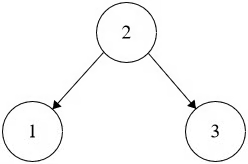

Input: root = [2,1,3], k = 1

Output: 1

Example 2:

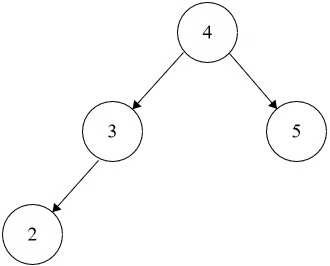

Input: root = [4,3,5,2,null], k = 4

Output: 5

In [ ]:
from typing import Optional, List
from collections import deque

In [ ]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

# Morris Traversal
class Solution:
    def kthSmallest(self, root: Optional[TreeNode], k: int) -> int:
        q = deque()
        curr = root
        while curr:
            if curr.left is None:
                q.append(curr.val)
                curr = curr.right
            else:
                pre = curr.left
                while pre.right and pre.right != curr:
                    pre = pre.right
                if pre.right is None:
                    pre.right = curr
                    curr = curr.left
                else:
                    pre.right = None
                    q.append(curr.val)
                    curr = curr.right

        return q[k - 1]

# Brute Force

Intuition

A Binary Search Tree (BST) has a special property:

Left subtree < root < right subtree

But this brute-force method does not use the BST property.

We simply:

Traverse the entire tree and collect all node values.

Sort the collected values.

The k-th smallest element is at index k-1 in the sorted list.

Algorithm

Create an empty list arr.

Perform DFS on the tree:

For every node, append its value to arr.

Sort arr.

Return arr[k-1].


In [ ]:
# Time Complexity: O(nlogn)
# Space Complexity: O(n)
class Solution:
    def kthSmallest(self, root: Optional[TreeNode], k: int) -> int:
        arr = []

        def dfs(node):
            if not node:
                return

            arr.append(node.val)
            dfs(node.left)
            dfs(node.right)

        dfs(root)
        arr.sort()
        return arr[k - 1]

# Inorder Traversal

Intuition

A Binary Search Tree (BST) has an important property:

Inorder Traversal (Left → Node → Right) always gives values in sorted order.

So instead of collecting all values and sorting them manually, we can:

Do an inorder traversal.

This automatically produces values in ascending order.

The k-th element in this inorder list is the answer.

This makes the solution more efficient and uses the BST’s inherent structure.

Algorithm

Create an empty list arr.

Perform inorder DFS:

Visit the left subtree.

Add the current node's value to arr.

Visit the right subtree.

After traversal, arr will be sorted.

Return arr[k-1].


In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def kthSmallest(self, root: Optional[TreeNode], k: int) -> int:
        arr = []

        def dfs(node):
            if not node:
                return

            dfs(node.left)
            arr.append(node.val)
            dfs(node.right)

        dfs(root)
        return arr[k - 1]

# Recursive DFS (Optimal)

Intuition

In a BST, the inorder traversal (Left → Node → Right) naturally visits nodes in sorted order.

So instead of storing all values, we can:

Traverse the tree in inorder,

Count nodes as we visit them,

Stop as soon as we visit the k-th smallest node.

This avoids storing all node values, and the early return lets us stop once the k-th smallest node is found.

Algorithm

Keep a counter cnt = k.

Perform an inorder DFS:

Go left.

If cnt == 0, return early (answer already found).

Decrease cnt.

If cnt == 0, record this node's value (this is the k-th smallest).

Go right only if the answer has not been found yet.

Return the recorded value.

In [ ]:
# Time Complexity: O(h+k) in terms of nodes visited, worst-case O(n)
# Space Complexity: O(h) for the recursion stack, worst-case O(n)
class Solution:
    def kthSmallest(self, root: Optional[TreeNode], k: int) -> int:
        cnt = k
        res = root.val

        def dfs(node):
            nonlocal cnt, res
            if not node:
                return

            dfs(node.left)
            if cnt == 0:
                return
            cnt -= 1
            if cnt == 0:
                res = node.val
                return
            dfs(node.right)

        dfs(root)
        return res

# Iterative DFS (Optimal)

Intuition

In a BST, an inorder traversal (left -> node -> right) gives nodes in sorted order.

Instead of recursion, we simulate this traversal with a stack:

Push all left nodes (go as deep as possible).

Pop the top node - this is the next smallest value.

Move to its right subtree and repeat.

When we pop the k-th node, that's our answer.

This way, we only visit nodes until we reach the k-th smallest — no need to traverse the whole tree.

Algorithm

Initialize an empty stack and set curr = root.

While either stack is not empty or curr is not null:

Push all left nodes into the stack (curr = curr.left).

Pop from the stack - this is the next smallest node.

Decrement k. If k == 0, return that node's value.

Move to the right subtree (curr = curr.right).

The popped k-th node is the answer.

In [ ]:
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def kthSmallest(self, root: Optional[TreeNode], k: int) -> int:
        stack = []
        curr = root

        while stack or curr:
            while curr:
                stack.append(curr)
                curr = curr.left
            curr = stack.pop()
            k -= 1
            if k == 0:
                return curr.val
            curr = curr.right